# FastOTF2Converter Memory Scaling Analysis

Submits converter runs across multiple input trace sizes (fixed node count),
parses `--memTrack` output from stdout, and visualizes memory scaling
with extrapolation to predict when more nodes are needed.

Memory usage is independent of node count (for 2+ nodes) — data just gets
distributed across more locales — so we only vary input size.

## TODO (Brandon)

- [ ] Add environment setup cells: clone [e4s-cl-setup](https://github.com/arezaii/e4s-cl-setup), create e4s-cl profile, build/pull the OFI container
- [ ] Add full pipeline notebook: trace collection → OTF2 conversion → Parquet → Ampere analysis
- [ ] Add sorting-location comparison notebook: compare pipeline performance based on where sorting happens
- [ ] Reproduce Shreyas's scaling results before extending


In [30]:
import subprocess
import time
import re
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np

## Configuration

Edit these cells to match your environment and desired test matrix.

In [ ]:
# === Environment Setup ===
E4S_SETUP_DIR = Path("/lus/scratch/khandeka/dev/e4s-cl-setup")

SBATCH_SCRIPT = E4S_SETUP_DIR / "bin/submit-fastotf2.sbatch"

IMAGE = "/lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/fastotf2-converter-ofi.sif"
APP = "/workspace/fastotf2/apps/FastOTF2Converter/target/release/FastOTF2Converter_real"

STRATEGY = "locgroup_dist_block"
FORMAT = "PARQUET"

# --- Single timestamped output folder for everything ---
HOST_OUT_ROOT = Path("/lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/apps/FastOTF2Converter/out")
RUN_TAG = f"mem_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
RUN_DIR = HOST_OUT_ROOT / RUN_TAG

JOB_LOG_DIR = RUN_DIR / "slurm_logs"
PLOTS_DIR = RUN_DIR / "plots"

# Container paths
CONTAINER_RUN_BASE = f"/out/{RUN_TAG}"
CONTAINER_OUTPUT_BASE = f"{CONTAINER_RUN_BASE}/pq"

# Fixed node count — memory distribution is input-size-dependent, not node-count-dependent
NODE_COUNT = 4

NUM_TRIALS = 2
WARMUP = False
POLL_INTERVAL_S = 15
MAX_WAIT_S = 12 * 60 * 60

# Create host directories
RUN_DIR.mkdir(parents=True, exist_ok=False)
JOB_LOG_DIR.mkdir(parents=True, exist_ok=False)
PLOTS_DIR.mkdir(parents=True, exist_ok=False)

if not SBATCH_SCRIPT.exists():
    raise FileNotFoundError(f"Missing sbatch script: {SBATCH_SCRIPT}")

print(f"RUN_TAG: {RUN_TAG}")
print(f"RUN_DIR: {RUN_DIR}")
print(f"  slurm_logs: {JOB_LOG_DIR}")
print(f"NODE_COUNT: {NODE_COUNT}")
print(f"NUM_TRIALS: {NUM_TRIALS}")

RUN_TAG: mem_20260512_030916
RUN_DIR: /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/apps/FastOTF2Converter/out/mem_20260512_030916
  slurm_logs: /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/apps/FastOTF2Converter/out/mem_20260512_030916/slurm_logs
NODE_COUNT: 4
NUM_TRIALS: 2


In [32]:
# === Test Matrix ===

HOST_TRACE_ROOT = Path("/lus/bnchlu1/adt/otf2-traces/frontier")
CONTAINER_TRACE_ROOT = Path("/traces")

TRACE_INPUTS = {
    2:  "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-2-node-single-HPL-run/traces.otf2",
    4:  "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-4-node-single-HPL-run/traces.otf2",
    8:  "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-8-node-single-HPL-run/traces.otf2",
    16: "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-16-node-single-HPL-run/traces.otf2",
    32: "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-32-node-single-HPL-run/traces.otf2",
}

print(f"Input sizes: {sorted(TRACE_INPUTS.keys())}")
print(f"Node count: {NODE_COUNT}")
print(f"Total jobs: {len(TRACE_INPUTS) * NUM_TRIALS}")

Input sizes: [2, 4, 8, 16, 32]
Node count: 4
Total jobs: 10


## Validate Slurm Tooling

Run this once to confirm `sbatch`, `squeue`, and optional `sacct` are available.

In [33]:
def run_local_cmd(args: list[str], cwd: Path | None = None) -> subprocess.CompletedProcess:
    """Run a local command (no setup-script sourcing required)."""
    return subprocess.run(
        args,
        cwd=str(cwd or E4S_SETUP_DIR),
        capture_output=True,
        text=True,
        check=False,
    )


for tool in ["sbatch", "squeue", "sacct"]:
    result = run_local_cmd(["bash", "-lc", f"command -v {tool}"])
    status = "found" if result.returncode == 0 else "missing"
    print(f"{tool}: {status}")

sbatch: found
squeue: found
sacct: found


## Run Memory Matrix

In [34]:
def to_container_trace_path(host_trace_path: str) -> str:
    """Map host trace path to container path using configured bind mount roots."""
    host_path = Path(host_trace_path).resolve()
    host_root = HOST_TRACE_ROOT.resolve()
    try:
        relative = host_path.relative_to(host_root)
    except ValueError as exc:
        raise ValueError(
            f"Trace path {host_path} is outside mounted host root {host_root}. "
            f"Update HOST_TRACE_ROOT/CONTAINER_TRACE_ROOT or TRACE_INPUTS."
        ) from exc
    return str(CONTAINER_TRACE_ROOT / relative)


def ensure_container_directory(path: str) -> None:
    """Create a directory inside the container/mounted output space before runs."""
    result = run_local_cmd(["e4s-cl", "launch", "--image", IMAGE, "mkdir", "-p", path])
    if result.returncode != 0:
        raise RuntimeError(
            f"Failed to create container directory {path}: {result.stderr.strip() or result.stdout.strip()}"
        )


def submit_job(
    *,
    input_size: int,
    node_count: int,
    trial: int,
    trace_path: str,
    container_output_dir: str,
    warmup: bool = False,
) -> dict:
    """Submit one sbatch job and return job metadata."""
    tag = "warmup" if warmup else f"trial{trial}"
    job_name = f"mem-s{input_size}-n{node_count}-{tag}"
    out_file = JOB_LOG_DIR / f"{job_name}-%j.out"
    err_file = JOB_LOG_DIR / f"{job_name}-%j.err"

    exports = {
        "INPUT_TRACE": trace_path,
        "OUTPUT_DIR": container_output_dir,
        "LOCALES": str(node_count),
        "SRUN_NODES": str(node_count),
        "SRUN_TASKS": str(node_count),
        "IMAGE": IMAGE,
        "APP": APP,
        "FORMAT": FORMAT,
        "STRATEGY": STRATEGY,
        "MEM_TRACK": "true",
    }
    export_arg = "ALL," + ",".join(f"{k}={v}" for k, v in exports.items())

    cmd = [
        "sbatch",
        "--parsable",
        "--job-name",
        job_name,
        "--nodes",
        str(node_count),
        "--ntasks",
        str(node_count),
        "--output",
        str(out_file),
        "--error",
        str(err_file),
        "--export",
        export_arg,
        str(SBATCH_SCRIPT),
    ]

    result = run_local_cmd(cmd)
    if result.returncode != 0:
        raise RuntimeError(f"sbatch failed: {result.stderr.strip()}")

    job_id = result.stdout.strip().split(";")[0]
    if not job_id.isdigit():
        raise RuntimeError(f"Could not parse job ID from sbatch output: {result.stdout!r}")

    return {
        "job_id": int(job_id),
        "job_name": job_name,
        "out_file_template": out_file,
        "err_file_template": err_file,
    }


def get_slurm_state(job_id: int) -> str:
    """Return terminal state from sacct when available."""
    result = run_local_cmd([
        "sacct",
        "-j",
        str(job_id),
        "--format=State",
        "--noheader",
        "--parsable2",
    ])
    if result.returncode != 0:
        return "UNKNOWN"

    states = [line.strip() for line in result.stdout.splitlines() if line.strip()]
    if not states:
        return "UNKNOWN"

    normalized = [s.split()[0] for s in states]
    for state in normalized:
        if state != "UNKNOWN":
            return state
    return "UNKNOWN"


def wait_for_job(job_id: int, poll_interval_s: int = POLL_INTERVAL_S, timeout_s: int = MAX_WAIT_S) -> str:
    """Poll squeue until the job leaves the queue, then query terminal state."""
    start = time.time()
    while True:
        if (time.time() - start) > timeout_s:
            raise TimeoutError(f"Job {job_id} did not complete within {timeout_s} seconds")

        q = run_local_cmd(["squeue", "-h", "-j", str(job_id), "-o", "%T"])
        state = q.stdout.strip() if q.returncode == 0 else ""
        if not state:
            return get_slurm_state(job_id)

        time.sleep(poll_interval_s)


def resolve_job_file(template_path: Path, job_id: int) -> Path:
    """Resolve %j placeholders in configured sbatch output/error paths."""
    return Path(str(template_path).replace("%j", str(job_id)))


print("Helpers defined. Jobs will export MEM_TRACK=true.")

Helpers defined. Jobs will export MEM_TRACK=true.


In [35]:
def run_memory_matrix():
    """Submit memory-tracking runs across all input sizes at fixed node count.

    Fire-all-then-wait-all: submit every job upfront, then poll until all complete.
    Memory data is parsed from stdout (.out files) after completion.
    """
    ensure_container_directory(CONTAINER_OUTPUT_BASE)
    print(f"Container output base: {CONTAINER_OUTPUT_BASE}")

    input_sizes = sorted(TRACE_INPUTS.keys())
    total_runs = len(input_sizes) * NUM_TRIALS
    print(f"Submitting {len(input_sizes)} input sizes x {NUM_TRIALS} trial(s) = {total_runs} jobs")
    print(f"Fixed node count: {NODE_COUNT}")
    print("=" * 80)

    # ── Phase 1: Submit all jobs ──────────────────────────────────────────
    pending = []  # list of dicts with job metadata
    for i, input_size in enumerate(input_sizes, 1):
        host_trace_path = TRACE_INPUTS[input_size]
        container_trace_path = to_container_trace_path(host_trace_path)
        print(f"\n[{i}/{len(input_sizes)}] size={input_size}, nodes={NODE_COUNT}")
        print(f"  trace: {container_trace_path}")

        for trial in range(1, NUM_TRIALS + 1):
            container_output_dir = f"{CONTAINER_OUTPUT_BASE}/size{input_size}_nl{NODE_COUNT}_trial{trial}"
            ts = datetime.now().isoformat()

            try:
                job = submit_job(
                    input_size=input_size,
                    node_count=NODE_COUNT,
                    trial=trial,
                    trace_path=container_trace_path,
                    container_output_dir=container_output_dir,
                )
                job_id = job["job_id"]
                print(f"  Trial {trial}: submitted job {job_id}")
                pending.append({
                    "input_size": input_size,
                    "node_count": NODE_COUNT,
                    "trial": trial,
                    "job_id": job_id,
                    "out_file_template": job["out_file_template"],
                    "timestamp": ts,
                })
            except Exception as exc:
                print(f"  Trial {trial}: SUBMIT FAILED — {exc}")
                pending.append({
                    "input_size": input_size,
                    "node_count": NODE_COUNT,
                    "trial": trial,
                    "job_id": None,
                    "slurm_state": "SUBMIT_FAIL",
                    "out_file": None,
                    "timestamp": ts,
                })

    submitted = [p for p in pending if p["job_id"] is not None]
    print(f"\n{'=' * 80}")
    print(f"Submitted {len(submitted)}/{total_runs} jobs. Waiting for completion...")

    # ── Phase 2: Poll all jobs until done ─────────────────────────────────
    remaining = {p["job_id"] for p in submitted}
    finished = {}  # job_id -> slurm_state
    start = time.time()

    while remaining:
        if (time.time() - start) > MAX_WAIT_S:
            print(f"TIMEOUT after {MAX_WAIT_S}s — {len(remaining)} jobs still running")
            for jid in remaining:
                finished[jid] = "TIMEOUT"
            break

        # Batch check: which jobs are still in the queue?
        q = run_local_cmd(["squeue", "-h", "-j", ",".join(str(j) for j in remaining), "-o", "%i"])
        still_queued = set()
        if q.returncode == 0:
            still_queued = {int(line.strip()) for line in q.stdout.splitlines() if line.strip().isdigit()}

        newly_done = remaining - still_queued
        for jid in newly_done:
            state = get_slurm_state(jid)
            finished[jid] = state
            print(f"  Job {jid}: {state}")

        remaining = still_queued
        if remaining:
            time.sleep(POLL_INTERVAL_S)

    # ── Phase 3: Collect results ──────────────────────────────────────────
    results = []
    for p in pending:
        if p["job_id"] is None:
            results.append(p)
            continue

        jid = p["job_id"]
        slurm_state = finished.get(jid, "UNKNOWN")
        out_file = resolve_job_file(p["out_file_template"], jid)
        results.append({
            "input_size": p["input_size"],
            "node_count": p["node_count"],
            "trial": p["trial"],
            "job_id": jid,
            "slurm_state": slurm_state,
            "out_file": str(out_file),
            "timestamp": p["timestamp"],
        })

    print(f"\nAll done. {sum(1 for r in results if r.get('slurm_state') == 'COMPLETED')}/{total_runs} COMPLETED")
    return pd.DataFrame(results)


# Run the matrix
df_jobs = run_memory_matrix()

Container output base: /out/mem_20260512_030916/pq
Submitting 5 input sizes x 2 trial(s) = 10 jobs
Fixed node count: 4

[1/5] size=2, nodes=4
  trace: /traces/frontier-2-node-single-HPL-run/traces.otf2
  Trial 1: submitted job 1467817
  Trial 2: submitted job 1467818

[2/5] size=4, nodes=4
  trace: /traces/frontier-4-node-single-HPL-run/traces.otf2
  Trial 1: submitted job 1467819
  Trial 2: submitted job 1467820

[3/5] size=8, nodes=4
  trace: /traces/frontier-8-node-single-HPL-run/traces.otf2
  Trial 1: submitted job 1467821
  Trial 2: submitted job 1467822

[4/5] size=16, nodes=4
  trace: /traces/frontier-16-node-single-HPL-run/traces.otf2
  Trial 1: submitted job 1467823
  Trial 2: submitted job 1467824

[5/5] size=32, nodes=4
  trace: /traces/frontier-32-node-single-HPL-run/traces.otf2
  Trial 1: submitted job 1467825
  Trial 2: submitted job 1467826

Submitted 10/10 jobs. Waiting for completion...


KeyboardInterrupt: 

## Job Manifest

In [ ]:
manifest_path = RUN_DIR / "manifest.csv"
df_jobs.to_csv(manifest_path, index=False)
print(f"Manifest saved: {manifest_path}")
display(df_jobs)

---

## Results Analysis

Everything below is **independent** of the data-generation cells above.
You can restart the kernel and run from here with only a `JOB_LOG_DIR` path
pointing at a completed run's `slurm_logs/` folder containing `.out` files.

In [43]:
# === Analysis Configuration (self-contained) ===
import re
from pathlib import Path
import pandas as pd
import numpy as np

# Point this at the slurm_logs subdirectory of a completed run.
# If running in the same session as data generation, this is derived from RUN_DIR.
# Otherwise, paste the path to a previous run's slurm_logs folder.
# HOST_LOG_DIR = JOB_LOG_DIR
# HOST_LOG_DIR = Path("/path/to/completed/run/slurm_logs")
HOST_LOG_DIR = Path("/lus/scratch/khandeka/dev/hpc-ai-adv-dev/fastotf2/apps/FastOTF2Converter/out/mem_20260512_095649/slurm_logs")

# Actual trace data sizes on disk (GB)
TRACE_SIZES_GB = {2: 0.7, 4: 2.0, 8: 5.6, 16: 12.0, 32: 33.0}

# Available RAM per node (GiB) — used for extrapolation thresholds
RAM_PER_NODE_GIB = 512  # Frontier nodes

print(f"Loading memory data from .out files in: {HOST_LOG_DIR}")
print(f"(To analyze a past run, set HOST_LOG_DIR to its slurm_logs/ folder)")

Loading memory data from .out files in: /lus/scratch/khandeka/dev/hpc-ai-adv-dev/fastotf2/apps/FastOTF2Converter/out/mem_20260512_095649/slurm_logs
(To analyze a past run, set HOST_LOG_DIR to its slurm_logs/ folder)


In [44]:
# === Memory Report Parser ===

# Regex for delta RSS lines (printed inside === Memory Report === block, but we scan entire file)
_RE_DELTA_RSS = re.compile(
    r'Locale\s+(\d+):\s+peak RSS=([\d.]+)\s+GiB\s+delta RSS.*?=([\d.]+)\s+GiB'
)

# Regex for Chapel memStats HWM lines (may appear outside sentinel block due to coforall)
_RE_HWM = re.compile(
    r'memStats:\s+node\s+(\d+)\s+Allocation High Water Mark:\s+(\d+)'
)

# Regex to extract input_size and node_count from job name in the .out file
# Matches job names like: mem-s2-n4-trial1-12345.out  or  f2-s2-n4-trial1-12345.out
_RE_JOB_FILE = re.compile(
    r'(?:mem|f2)-s(\d+)-n(\d+)-(?:trial(\d+)|warmup)'
)

# Fallback: extract from RUN METADATA block in .out file
_RE_INPUT_TRACE = re.compile(r'Input trace:.*?frontier-(\d+)-node')
_RE_LOCALES = re.compile(r'Locales \(-nl\):\s+(\d+)')


def parse_memory_report(filepath: Path) -> pd.DataFrame:
    """Parse memory report from a converter .out file.

    Extracts two values per locale:
      - delta_rss_gib: RSS growth during conversion (C/libOTF2 memory)
      - hwm_gib: Chapel Allocation High Water Mark (Chapel heap memory)
    These are summed to get total_mem_gib per locale.

    Scans the entire file (not just between sentinel lines) because Chapel's
    coforall causes memStats lines to print in parallel, often after the
    === End Memory Report === sentinel.
    """
    text = filepath.read_text()

    # Parse delta RSS per locale
    rss_records = {}
    for m in _RE_DELTA_RSS.finditer(text):
        locale_id = int(m.group(1))
        rss_records[locale_id] = {
            "peak_rss_gib": float(m.group(2)),
            "delta_rss_gib": float(m.group(3)),
        }

    # Parse Chapel HWM per locale
    hwm_records = {}
    for m in _RE_HWM.finditer(text):
        locale_id = int(m.group(1))
        hwm_records[locale_id] = int(m.group(2))

    if not rss_records and not hwm_records:
        return pd.DataFrame()

    # Merge on locale_id
    all_locales = sorted(set(rss_records.keys()) | set(hwm_records.keys()))
    rows = []
    for loc in all_locales:
        rss = rss_records.get(loc, {})
        hwm_bytes = hwm_records.get(loc, 0)
        hwm_gib = hwm_bytes / (1024 ** 3)
        delta_rss = rss.get("delta_rss_gib", 0.0)
        rows.append({
            "locale_id": loc,
            "peak_rss_gib": rss.get("peak_rss_gib", np.nan),
            "delta_rss_gib": delta_rss,
            "hwm_bytes": hwm_bytes,
            "hwm_gib": hwm_gib,
            "total_mem_gib": delta_rss + hwm_gib,
        })

    return pd.DataFrame(rows)


def _extract_job_metadata(filepath: Path) -> dict:
    """Extract input_size, node_count, trial from filename or file contents."""
    # Try filename first
    m = _RE_JOB_FILE.search(filepath.name)
    if m:
        return {
            "input_size": int(m.group(1)),
            "node_count": int(m.group(2)),
            "trial": int(m.group(3)) if m.group(3) else 0,
        }

    # Fallback: parse RUN METADATA block from file contents
    text = filepath.read_text()
    meta = {}
    m_trace = _RE_INPUT_TRACE.search(text)
    if m_trace:
        meta["input_size"] = int(m_trace.group(1))
    m_loc = _RE_LOCALES.search(text)
    if m_loc:
        meta["node_count"] = int(m_loc.group(1))
    meta.setdefault("trial", 1)
    return meta


def load_memory_data(log_dir: Path) -> pd.DataFrame:
    """Load and parse memory data from all .out files in a directory.

    Returns a DataFrame with columns:
      input_size, node_count, trial, locale_id, peak_rss_gib,
      delta_rss_gib, hwm_bytes, hwm_gib, total_mem_gib, data_size_gb
    """
    frames = []
    out_files = sorted(log_dir.glob("*.out"))
    if not out_files:
        print(f"No .out files found in {log_dir}")
        return pd.DataFrame()

    for filepath in out_files:
        df = parse_memory_report(filepath)
        if df.empty:
            print(f"  SKIP (no memory data): {filepath.name}")
            continue

        meta = _extract_job_metadata(filepath)
        for k, v in meta.items():
            df[k] = v
        df["source_file"] = filepath.name
        frames.append(df)

    if not frames:
        print("No memory data found in any .out files.")
        return pd.DataFrame()

    df_all = pd.concat(frames, ignore_index=True)
    if "input_size" in df_all.columns:
        df_all["data_size_gb"] = df_all["input_size"].map(TRACE_SIZES_GB)
    return df_all


df_mem = load_memory_data(HOST_LOG_DIR)
print(f"Loaded: {len(df_mem)} locale records from {df_mem['source_file'].nunique() if not df_mem.empty else 0} files")
if not df_mem.empty:
    print(f"Input sizes: {sorted(df_mem['input_size'].dropna().unique().astype(int))}")
    display(df_mem)

  SKIP (no memory data): mem-s32-n4-trial1-1468014.out
  SKIP (no memory data): mem-s32-n4-trial2-1468015.out
Loaded: 32 locale records from 8 files
Input sizes: [np.int64(2), np.int64(4), np.int64(8), np.int64(16)]


,locale_id,peak_rss_gib,delta_rss_gib,hwm_bytes,hwm_gib,total_mem_gib,input_size,node_count,trial,source_file,data_size_gb
0,0,385.248,27.85670,29069621552,27.073195,54.929895,16,4,1,mem-s16-n4-trial1-1468012.out,12.0
1,1,388.848,31.48500,33370675896,31.078864,62.563864,16,4,1,mem-s16-n4-trial1-1468012.out,12.0
2,2,388.874,31.46720,32396021584,30.171146,61.638346,16,4,1,mem-s16-n4-trial1-1468012.out,12.0
3,3,384.499,27.07650,25381492696,23.638357,50.714857,16,4,1,mem-s16-n4-trial1-1468012.out,12.0
4,0,385.228,27.84930,29013848824,27.021252,54.870552,16,4,2,mem-s16-n4-trial2-1468013.out,12.0
5,1,388.618,31.21130,34038725008,31.701033,62.912333,16,4,2,mem-s16-n4-trial2-1468013.out,12.0
6,2,387.091,29.68820,32131469416,29.924763,59.612963,16,4,2,mem-s16-n4-trial2-1468013.out,12.0
7,3,389.220,31.80160,28935170168,26.947977,58.749577,16,4,2,mem-s16-n4-trial2-1468013.out,12.0
8,0,359.507,2.12993,2242936328,2.088897,4.218827,2,4,1,mem-s2-n4-trial1-1468006.out,0.7
9,1,359.283,1.86955,2292188536,2.134767,4.004317,2,4,1,mem-s2-n4-trial1-1468006.out,0.7


### Graph 1 — Total Memory vs Input Size

Aggregate total memory (sum across all locales) vs input size.
Median line with min–max shaded band across trials.
Dashed line shows raw data size for reference.

**Memory Amplification Factor** (right panel) = Total Memory / Raw Data Size.
A factor of 20× means the converter needs 20 GiB of RAM for every 1 GB of input trace data.
This ratio captures all overhead: Chapel runtime, libOTF2 buffers, intermediate data structures, and distributed bookkeeping.
A flat line means overhead scales linearly with input — no super-linear blowup.

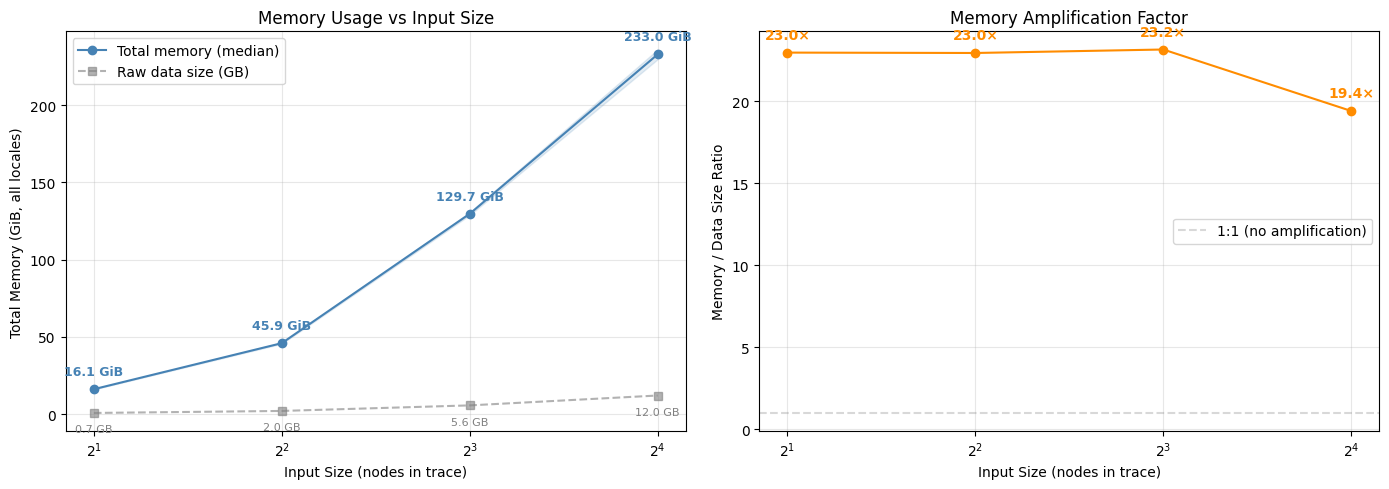

In [45]:
import matplotlib.pyplot as plt

if not df_mem.empty:
    # Aggregate: sum total_mem_gib across locales for each (input_size, trial)
    df_run_totals = (
        df_mem.groupby(["input_size", "trial", "data_size_gb"])
        .agg(
            total_mem_gib=("total_mem_gib", "sum"),
            total_delta_rss=("delta_rss_gib", "sum"),
            total_hwm=("hwm_gib", "sum"),
        )
        .reset_index()
    )

    stats = (
        df_run_totals.groupby(["input_size", "data_size_gb"])["total_mem_gib"]
        .agg(["median", "min", "max"])
        .reset_index()
        .sort_values("input_size")
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Left: Total memory vs input size ---
    ax = axes[0]
    sizes = stats["input_size"].values
    medians = stats["median"].values
    data_sizes = stats["data_size_gb"].values
    ax.plot(sizes, medians, marker="o", color="steelblue", label="Total memory (median)")
    ax.fill_between(sizes, stats["min"].values, stats["max"].values, alpha=0.15, color="steelblue")
    ax.plot(sizes, data_sizes, marker="s", linestyle="--", color="gray", alpha=0.6, label="Raw data size (GB)")
    # Data labels
    for s, med, ds in zip(sizes, medians, data_sizes):
        ax.annotate(f"{med:.1f} GiB", (s, med), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=9, fontweight="bold", color="steelblue")
        ax.annotate(f"{ds:.1f} GB", (s, ds), textcoords="offset points",
                    xytext=(0, -14), ha="center", fontsize=8, color="gray")
    ax.set_xlabel("Input Size (nodes in trace)")
    ax.set_ylabel("Total Memory (GiB, all locales)")
    ax.set_title("Memory Usage vs Input Size")
    ax.set_xscale("log", base=2)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- Right: Memory-to-data ratio ---
    ax = axes[1]
    ratio = medians / data_sizes
    ax.plot(sizes, ratio, marker="o", color="darkorange")
    # Data labels
    for s, r in zip(sizes, ratio):
        ax.annotate(f"{r:.1f}×", (s, r), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=10, fontweight="bold", color="darkorange")
    ax.set_xlabel("Input Size (nodes in trace)")
    ax.set_ylabel("Memory / Data Size Ratio")
    ax.set_title("Memory Amplification Factor")
    ax.set_xscale("log", base=2)
    ax.axhline(y=1.0, linestyle="--", color="gray", alpha=0.3, label="1:1 (no amplification)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No memory data available.")

### Graph 2 — Per-Locale Memory Breakdown

Stacked bar per locale showing delta RSS (C/libOTF2) vs Chapel HWM.
One subplot per input size. Shows how memory is distributed
and which component dominates.

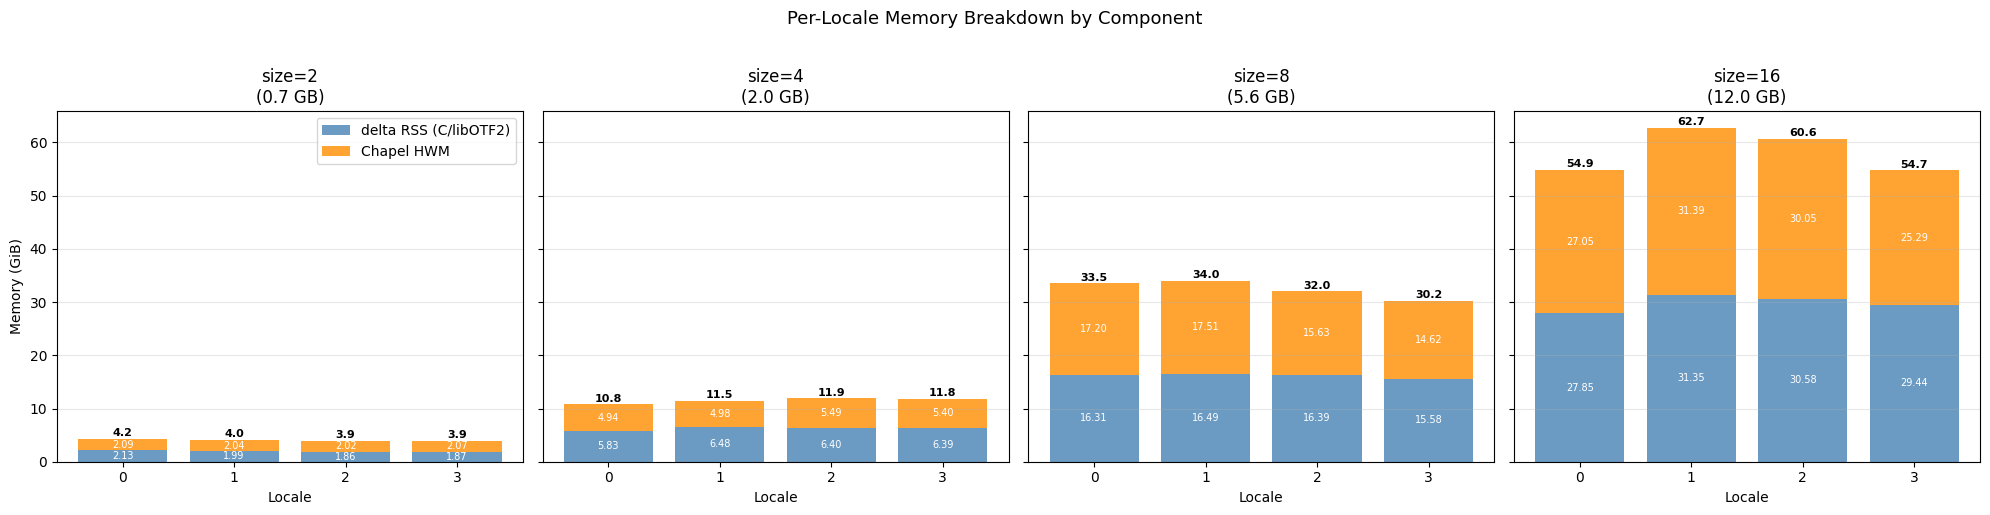

In [46]:
if not df_mem.empty:
    input_sizes = sorted(df_mem["input_size"].unique().astype(int))
    n_sizes = len(input_sizes)
    fig, axes = plt.subplots(1, n_sizes, figsize=(5 * n_sizes, 5), sharey=True, squeeze=False)
    axes = axes[0]

    for ax, isize in zip(axes, input_sizes):
        subset = df_mem[df_mem["input_size"] == isize]
        # Mean across trials per locale
        means = subset.groupby("locale_id")[["delta_rss_gib", "hwm_gib"]].mean()
        locales = means.index.values

        bars_rss = ax.bar(locales, means["delta_rss_gib"], label="delta RSS (C/libOTF2)", color="steelblue", alpha=0.8)
        bars_hwm = ax.bar(locales, means["hwm_gib"], bottom=means["delta_rss_gib"], label="Chapel HWM", color="darkorange", alpha=0.8)

        # Data labels: total on top, component values inside bars
        for loc in locales:
            rss = means.loc[loc, "delta_rss_gib"]
            hwm = means.loc[loc, "hwm_gib"]
            total = rss + hwm
            # Total on top of bar
            ax.text(loc, total + 0.15, f"{total:.1f}", ha="center", va="bottom",
                    fontsize=8, fontweight="bold")
            # RSS value inside bottom bar (if tall enough)
            if rss > 0.5:
                ax.text(loc, rss / 2, f"{rss:.2f}", ha="center", va="center",
                        fontsize=7, color="white")
            # HWM value inside top bar (if tall enough)
            if hwm > 0.5:
                ax.text(loc, rss + hwm / 2, f"{hwm:.2f}", ha="center", va="center",
                        fontsize=7, color="white")

        ax.set_xlabel("Locale")
        ax.set_title(f"size={isize}\n({TRACE_SIZES_GB.get(isize, '?')} GB)")
        ax.set_xticks(locales)
        ax.grid(True, alpha=0.3, axis="y")

    axes[0].set_ylabel("Memory (GiB)")
    axes[0].legend()
    fig.suptitle("Per-Locale Memory Breakdown by Component", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No memory data available.")

### Graph 3 — Memory Extrapolation & Node Requirements

Fits a power-law curve ($\text{mem} = a \cdot \text{size}^b$) to total memory vs data size,
then extrapolates to larger traces.

**How to read this graph**: Find your trace size on the x-axis, follow up to the blue
curve to read the projected total memory (left y-axis). Horizontal dashed lines show
how much RAM is available at common node counts (each Frontier node = 512 GiB).
When the blue curve crosses a line, you need at least that many nodes.

Specific projections for **300 GB** and **1.5 TB** traces are called out with
the exact memory and node count needed.

Power-law fit: total_mem = 23.32 × data_size^0.95  (R²=0.9973)
  300 GB trace → 5,309 GiB total memory → 11 nodes needed (at 512 GiB/node)
  1.5 TB trace → 24,556 GiB total memory → 48 nodes needed (at 512 GiB/node)


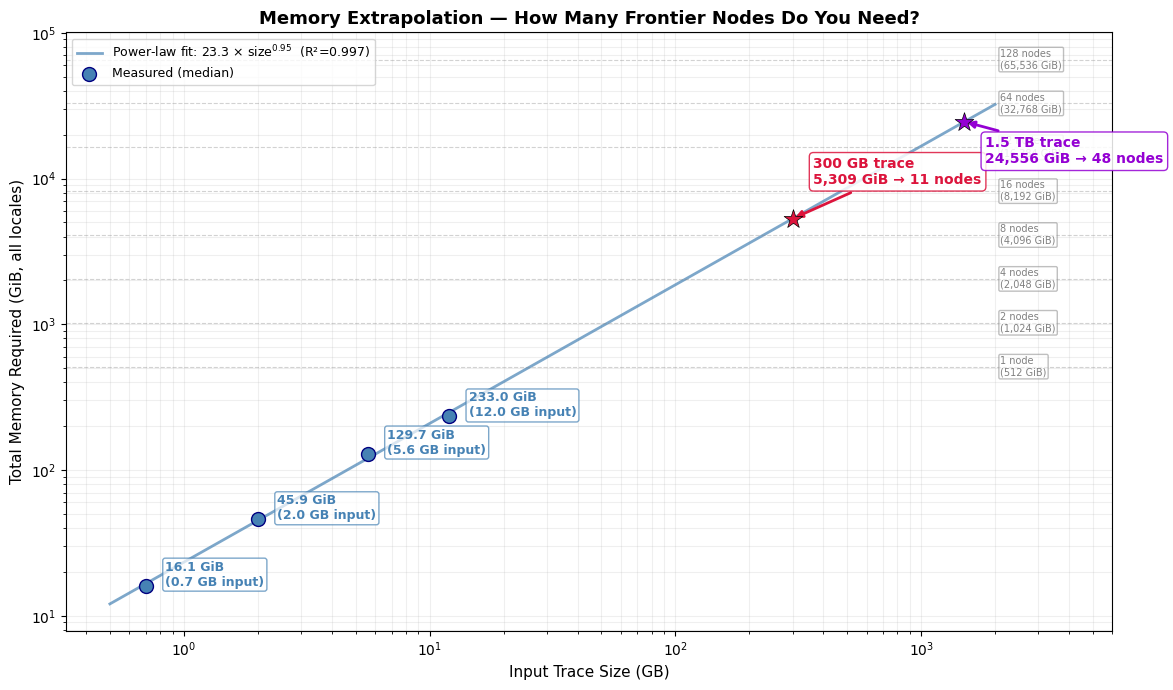


  PROJECTION SUMMARY  (model: mem = 23.3 × size^0.95)
  Frontier nodes have 512 GiB RAM each
  Trace Size      Total Mem (GiB)    Nodes Needed   
  ------------------------------------------------
       0.7 GB             16.1            1
       2.0 GB             45.9            1
       5.6 GB            129.7            1
      12.0 GB            233.0            1
       300 GB            5,309           11  ← projected
       1.5 TB           24,556           48  ← projected


In [47]:
import math

if not df_mem.empty:
    # Aggregate total memory per (input_size, trial)
    df_run_totals = (
        df_mem.groupby(["input_size", "trial", "data_size_gb"])
        .agg(total_mem_gib=("total_mem_gib", "sum"))
        .reset_index()
    )

    # Median across trials
    stats = (
        df_run_totals.groupby(["input_size", "data_size_gb"])
        .agg(total_median=("total_mem_gib", "median"))
        .reset_index()
        .sort_values("data_size_gb")
    )

    # Fit power law: log(mem) = log(a) + b * log(size)
    x = np.log(stats["data_size_gb"].values)
    y_total = np.log(stats["total_median"].values)
    coeffs_total = np.polyfit(x, y_total, 1)
    b_total, log_a_total = coeffs_total
    a_total = np.exp(log_a_total)

    # R²
    y_pred = np.polyval(coeffs_total, x)
    ss_res = np.sum((y_total - y_pred) ** 2)
    ss_tot = np.sum((y_total - np.mean(y_total)) ** 2)
    r_sq = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    print(f"Power-law fit: total_mem = {a_total:.2f} × data_size^{b_total:.2f}  (R²={r_sq:.4f})")

    # --- Projection targets ---
    target_sizes_gb = [300, 1500]  # 300 GB and 1.5 TB
    target_labels = ["300 GB", "1.5 TB"]

    for sz, label in zip(target_sizes_gb, target_labels):
        projected_mem = a_total * sz ** b_total
        nodes_needed = math.ceil(projected_mem / RAM_PER_NODE_GIB)
        print(f"  {label} trace → {projected_mem:,.0f} GiB total memory → {nodes_needed} nodes needed (at {RAM_PER_NODE_GIB} GiB/node)")

    # Extrapolation range
    x_extrap = np.linspace(np.log(0.5), np.log(2000), 300)
    sizes_extrap = np.exp(x_extrap)
    mem_extrap = a_total * sizes_extrap ** b_total

    # Measured points
    measured_sizes = stats["data_size_gb"].values
    measured_mem = stats["total_median"].values

    # ── Single clear figure ──
    fig, ax = plt.subplots(figsize=(12, 7))

    # Power-law extrapolation curve
    ax.plot(sizes_extrap, mem_extrap, "-", color="steelblue", alpha=0.7, linewidth=2,
            label=f"Power-law fit: {a_total:.1f} × size$^{{{b_total:.2f}}}$  (R²={r_sq:.3f})")

    # Measured data points
    ax.scatter(measured_sizes, measured_mem, s=100, zorder=5, color="steelblue",
               edgecolors="navy", linewidth=1, label="Measured (median)")
    for sz, mem in zip(measured_sizes, measured_mem):
        ax.annotate(f"{mem:.1f} GiB\n({sz:.1f} GB input)", (sz, mem),
                    textcoords="offset points", xytext=(14, 0), ha="left",
                    fontsize=9, fontweight="bold", color="steelblue",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="steelblue", alpha=0.7))

    # Node-count threshold lines (each node = RAM_PER_NODE_GIB)
    node_counts_to_show = [1, 2, 4, 8, 16, 32, 64, 128]
    for nc in node_counts_to_show:
        total_ram = nc * RAM_PER_NODE_GIB
        if total_ram < mem_extrap.min() * 0.5 or total_ram > mem_extrap.max() * 5:
            continue  # skip lines that are way off the chart
        ax.axhline(y=total_ram, linestyle="--", color="gray", alpha=0.35, linewidth=0.8)
        # Label on the right edge
        ax.text(sizes_extrap[-1] * 1.05, total_ram,
                f"{nc} node{'s' if nc > 1 else ''}\n({total_ram:,} GiB)",
                va="center", ha="left", fontsize=7, color="gray",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="gray", alpha=0.5))

    # Target projections
    colors_target = ["crimson", "darkviolet"]
    offsets_target = [(15, 25), (15, -30)]
    for sz, label, clr, ofs in zip(target_sizes_gb, target_labels, colors_target, offsets_target):
        proj_mem = a_total * sz ** b_total
        nodes = math.ceil(proj_mem / RAM_PER_NODE_GIB)
        ax.scatter([sz], [proj_mem], s=200, marker="*", color=clr, zorder=6, edgecolors="black", linewidth=0.5)
        ax.annotate(
            f"{label} trace\n{proj_mem:,.0f} GiB → {nodes} nodes",
            (sz, proj_mem), textcoords="offset points", xytext=ofs,
            ha="left", fontsize=10, fontweight="bold", color=clr,
            arrowprops=dict(arrowstyle="-|>", color=clr, lw=2),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=clr, alpha=0.85),
        )

    ax.set_xlabel("Input Trace Size (GB)", fontsize=11)
    ax.set_ylabel("Total Memory Required (GiB, all locales)", fontsize=11)
    ax.set_title("Memory Extrapolation — How Many Frontier Nodes Do You Need?", fontsize=13, fontweight="bold")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, alpha=0.2, which="both")

    # Expand right margin for node labels
    ax.set_xlim(right=sizes_extrap[-1] * 3)

    plt.tight_layout()
    plt.show()

    # Summary table
    print(f"\n{'='*70}")
    print(f"  PROJECTION SUMMARY  (model: mem = {a_total:.1f} × size^{b_total:.2f})")
    print(f"  Frontier nodes have {RAM_PER_NODE_GIB} GiB RAM each")
    print(f"{'='*70}")
    print(f"  {'Trace Size':<15} {'Total Mem (GiB)':<18} {'Nodes Needed':<15}")
    print(f"  {'-'*48}")
    for sz, mem in zip(measured_sizes, measured_mem):
        n = math.ceil(mem / RAM_PER_NODE_GIB)
        print(f"  {sz:>8.1f} GB     {mem:>12.1f}       {n:>6}")
    for sz, label in zip(target_sizes_gb, target_labels):
        proj_mem = a_total * sz ** b_total
        n = math.ceil(proj_mem / RAM_PER_NODE_GIB)
        print(f"  {label:>11s}     {proj_mem:>12,.0f}       {n:>6}  ← projected")
    print(f"{'='*70}")
else:
    print("No memory data available.")

### Graph 4 — Container vs Bare Metal Comparison

Side-by-side comparison of memory usage between container (e4s-cl) and
bare metal runs. Focuses on delta RSS and Chapel HWM (peak RSS differs
due to `CHPL_RT_MAX_HEAP_SIZE` settings and is not meaningful here).

**To use:** set `CONTAINER_OUT` and `BARE_METAL_OUT` to the paths of
`.out` files from matching runs (same input size and node count).

In [48]:
# === Configure paths to matching container and bare metal .out files ===
CONTAINER_OUT = Path("/lus/scratch/khandeka/dev/e4s-cl-setup/fastotf2-converter-1467785.out")
BARE_METAL_OUT = None  # Path("/path/to/bare-metal-run.out")

if CONTAINER_OUT and BARE_METAL_OUT and CONTAINER_OUT.exists() and BARE_METAL_OUT.exists():
    df_container = parse_memory_report(CONTAINER_OUT)
    df_container["env"] = "container"
    df_bare = parse_memory_report(BARE_METAL_OUT)
    df_bare["env"] = "bare_metal"

    df_compare = pd.concat([df_container, df_bare], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    locales = sorted(df_compare["locale_id"].unique())
    x = np.arange(len(locales))
    width = 0.35

    # --- Left: Delta RSS comparison ---
    ax = axes[0]
    container_vals = df_container.set_index("locale_id").loc[locales, "delta_rss_gib"].values
    bare_vals = df_bare.set_index("locale_id").loc[locales, "delta_rss_gib"].values
    ax.bar(x - width/2, container_vals, width, label="Container", color="steelblue", alpha=0.8)
    ax.bar(x + width/2, bare_vals, width, label="Bare Metal", color="darkorange", alpha=0.8)
    ax.set_xlabel("Locale")
    ax.set_ylabel("Delta RSS (GiB)")
    ax.set_title("Delta RSS: Container vs Bare Metal")
    ax.set_xticks(x)
    ax.set_xticklabels(locales)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

    # --- Right: Chapel HWM comparison ---
    ax = axes[1]
    container_vals = df_container.set_index("locale_id").loc[locales, "hwm_gib"].values
    bare_vals = df_bare.set_index("locale_id").loc[locales, "hwm_gib"].values
    ax.bar(x - width/2, container_vals, width, label="Container", color="steelblue", alpha=0.8)
    ax.bar(x + width/2, bare_vals, width, label="Bare Metal", color="darkorange", alpha=0.8)
    ax.set_xlabel("Locale")
    ax.set_ylabel("Chapel HWM (GiB)")
    ax.set_title("Chapel HWM: Container vs Bare Metal")
    ax.set_xticks(x)
    ax.set_xticklabels(locales)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

    # % difference table
    print("\n=== Percentage Difference (container vs bare metal) ===")
    print("Positive = container uses more; Negative = container uses less\n")
    for loc in locales:
        c = df_container[df_container["locale_id"] == loc].iloc[0]
        b = df_bare[df_bare["locale_id"] == loc].iloc[0]
        rss_pct = (c["delta_rss_gib"] - b["delta_rss_gib"]) / b["delta_rss_gib"] * 100 if b["delta_rss_gib"] > 0 else float("nan")
        hwm_pct = (c["hwm_gib"] - b["hwm_gib"]) / b["hwm_gib"] * 100 if b["hwm_gib"] > 0 else float("nan")
        total_c = c["delta_rss_gib"] + c["hwm_gib"]
        total_b = b["delta_rss_gib"] + b["hwm_gib"]
        total_pct = (total_c - total_b) / total_b * 100 if total_b > 0 else float("nan")
        print(f"  Locale {loc}: deltaRSS {rss_pct:+.2f}%  Chapel HWM {hwm_pct:+.2f}%  Total {total_pct:+.2f}%")

elif CONTAINER_OUT and CONTAINER_OUT.exists() and not BARE_METAL_OUT:
    print("Only container .out file provided. Set BARE_METAL_OUT to enable comparison.")
    print("\nContainer memory report:")
    display(parse_memory_report(CONTAINER_OUT))
else:
    print("Set CONTAINER_OUT and BARE_METAL_OUT to valid .out file paths to enable comparison.")

Only container .out file provided. Set BARE_METAL_OUT to enable comparison.

Container memory report:


,locale_id,peak_rss_gib,delta_rss_gib,hwm_bytes,hwm_gib,total_mem_gib
0,0,359.485,2.13039,2242859192,2.088825,4.219215
1,1,359.284,1.87756,2292194616,2.134773,4.012333
2,2,359.286,1.87324,2273564552,2.117422,3.990662
3,3,359.297,1.87252,2278253592,2.121789,3.994309


### Save Plots (optional)

Run this cell to save all graphs as PNG files to the run directory.
Skipped by default — only run when you want to export figures.

In [49]:
SAVE_PLOTS = True

if SAVE_PLOTS:
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)

    # --- Graph 1: Total Memory vs Input Size + Amplification Factor ---
    if not df_mem.empty:
        df_rt = (
            df_mem.groupby(["input_size", "trial", "data_size_gb"])
            .agg(total_mem_gib=("total_mem_gib", "sum"), total_delta_rss=("delta_rss_gib", "sum"), total_hwm=("hwm_gib", "sum"))
            .reset_index()
        )
        st = df_rt.groupby(["input_size", "data_size_gb"])["total_mem_gib"].agg(["median", "min", "max"]).reset_index().sort_values("input_size")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax = axes[0]
        sizes_s = st["input_size"].values; meds = st["median"].values; dsizes = st["data_size_gb"].values
        ax.plot(sizes_s, meds, marker="o", color="steelblue", label="Total memory")
        ax.fill_between(sizes_s, st["min"], st["max"], alpha=0.15, color="steelblue")
        ax.plot(sizes_s, dsizes, marker="s", linestyle="--", color="gray", alpha=0.6, label="Data size")
        for s, med, ds in zip(sizes_s, meds, dsizes):
            ax.annotate(f"{med:.1f} GiB", (s, med), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, fontweight="bold", color="steelblue")
            ax.annotate(f"{ds:.1f} GB", (s, ds), textcoords="offset points", xytext=(0, -14), ha="center", fontsize=8, color="gray")
        ax.set_xlabel("Input Size"); ax.set_ylabel("Total Memory (GiB)")
        ax.set_title("Memory Usage vs Input Size"); ax.set_xscale("log", base=2)
        ax.legend(); ax.grid(True, alpha=0.3)
        ax = axes[1]
        ratio = meds / dsizes
        ax.plot(sizes_s, ratio, marker="o", color="darkorange")
        for s, r in zip(sizes_s, ratio):
            ax.annotate(f"{r:.1f}×", (s, r), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10, fontweight="bold", color="darkorange")
        ax.set_xlabel("Input Size"); ax.set_ylabel("Memory / Data Ratio")
        ax.set_title("Memory Amplification Factor"); ax.set_xscale("log", base=2)
        ax.axhline(y=1.0, linestyle="--", color="gray", alpha=0.3, label="1:1"); ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        fig.savefig(PLOTS_DIR / "graph1_memory_vs_input.png", dpi=150, bbox_inches="tight")
        plt.close(fig)

    # --- Graph 2: Per-Locale Breakdown ---
    if not df_mem.empty:
        input_sizes = sorted(df_mem["input_size"].unique().astype(int))
        n_sizes = len(input_sizes)
        fig, axes = plt.subplots(1, n_sizes, figsize=(5 * n_sizes, 5), sharey=True, squeeze=False)
        axes = axes[0]
        for ax, isize in zip(axes, input_sizes):
            subset = df_mem[df_mem["input_size"] == isize]
            means = subset.groupby("locale_id")[["delta_rss_gib", "hwm_gib"]].mean()
            locales = means.index.values
            ax.bar(locales, means["delta_rss_gib"], label="delta RSS", color="steelblue", alpha=0.8)
            ax.bar(locales, means["hwm_gib"], bottom=means["delta_rss_gib"], label="Chapel HWM", color="darkorange", alpha=0.8)
            for loc in locales:
                rss = means.loc[loc, "delta_rss_gib"]; hwm = means.loc[loc, "hwm_gib"]; total = rss + hwm
                ax.text(loc, total + 0.15, f"{total:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
                if rss > 0.5: ax.text(loc, rss / 2, f"{rss:.2f}", ha="center", va="center", fontsize=7, color="white")
                if hwm > 0.5: ax.text(loc, rss + hwm / 2, f"{hwm:.2f}", ha="center", va="center", fontsize=7, color="white")
            ax.set_xlabel("Locale")
            ax.set_title(f"size={isize}\n({TRACE_SIZES_GB.get(isize, '?')} GB)")
            ax.set_xticks(locales); ax.grid(True, alpha=0.3, axis="y")
        axes[0].set_ylabel("Memory (GiB)"); axes[0].legend()
        fig.suptitle("Per-Locale Memory Breakdown", fontsize=13, y=1.02)
        plt.tight_layout()
        fig.savefig(PLOTS_DIR / "graph2_locale_breakdown.png", dpi=150, bbox_inches="tight")
        plt.close(fig)

    # --- Graph 3: Node Requirements & Extrapolation ---
    if not df_mem.empty:
        df_rt2 = (
            df_mem.groupby(["input_size", "trial", "data_size_gb"])
            .agg(total_mem_gib=("total_mem_gib", "sum"))
            .reset_index()
        )
        st2 = df_rt2.groupby(["input_size", "data_size_gb"]).agg(
            total_median=("total_mem_gib", "median")
        ).reset_index().sort_values("data_size_gb")
        x_fit = np.log(st2["data_size_gb"].values)
        y_t = np.log(st2["total_median"].values)
        ct = np.polyfit(x_fit, y_t, 1)
        at, bt = np.exp(ct[1]), ct[0]
        x_e = np.linspace(np.log(0.5), np.log(2000), 300)
        s_e = np.exp(x_e); m_e = at * s_e**bt
        m_sizes = st2["data_size_gb"].values; m_mem = st2["total_median"].values
        tgt_sizes = [300, 1500]; tgt_labels = ["300 GB", "1.5 TB"]; tgt_colors = ["crimson", "darkviolet"]

        fig, ax = plt.subplots(figsize=(12, 7))
        ax.plot(s_e, m_e, "-", color="steelblue", alpha=0.7, linewidth=2, label=f"Fit: {at:.1f} × size$^{{{bt:.2f}}}$")
        ax.scatter(m_sizes, m_mem, s=100, zorder=5, color="steelblue", edgecolors="navy", linewidth=1, label="Measured")
        for sz, mem in zip(m_sizes, m_mem):
            ax.annotate(f"{mem:.1f} GiB", (sz, mem), textcoords="offset points", xytext=(14, 0), ha="left", fontsize=9, fontweight="bold", color="steelblue", bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="steelblue", alpha=0.7))
        for nc in [1, 2, 4, 8, 16, 32, 64, 128]:
            tr = nc * RAM_PER_NODE_GIB
            if tr < m_e.min() * 0.5 or tr > m_e.max() * 5: continue
            ax.axhline(y=tr, linestyle="--", color="gray", alpha=0.35, linewidth=0.8)
            ax.text(s_e[-1] * 1.05, tr, f"{nc} node{'s' if nc > 1 else ''}\n({tr:,} GiB)", va="center", ha="left", fontsize=7, color="gray", bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="gray", alpha=0.5))
        ofs = [(15, 25), (15, -30)]
        for sz, label, clr, o in zip(tgt_sizes, tgt_labels, tgt_colors, ofs):
            pm = at * sz**bt; pn = math.ceil(pm / RAM_PER_NODE_GIB)
            ax.scatter([sz], [pm], s=200, marker="*", color=clr, zorder=6, edgecolors="black", linewidth=0.5)
            ax.annotate(f"{label} trace\n{pm:,.0f} GiB → {pn} nodes", (sz, pm), textcoords="offset points", xytext=o, ha="left", fontsize=10, fontweight="bold", color=clr, arrowprops=dict(arrowstyle="-|>", color=clr, lw=2), bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=clr, alpha=0.85))
        ax.set_xlabel("Trace Size (GB)"); ax.set_ylabel("Total Memory (GiB)")
        ax.set_title("Memory Extrapolation — Frontier Nodes Required", fontsize=13, fontweight="bold")
        ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(right=s_e[-1] * 3)
        ax.legend(fontsize=9, loc="upper left"); ax.grid(True, alpha=0.2, which="both")
        plt.tight_layout()
        fig.savefig(PLOTS_DIR / "graph3_node_requirements.png", dpi=150, bbox_inches="tight")
        plt.close(fig)

    print(f"Plots saved to: {PLOTS_DIR}")
else:
    print("SAVE_PLOTS is False — skipping.")

Plots saved to: /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/apps/FastOTF2Converter/out/mem_20260512_030916/plots
